# 04 · Level-1 flux distribution and cumulative budget by variant

The same flux distribution and running (cumulative) budget as
[notebook 09](09_cumulative_qc_fluxes.ipynb), but built on the **Level-1 EddyPro
fluxes**, before the flux processing chain (no quality flags, no storage term, no
outlier removal, no USTAR filtering). It is the pre-quality-control counterpart of
the cumulative comparison.

Like [notebook 03](03_level1_merged_figures.ipynb), this notebook only draws
figures. The reading and merging happened once in
[notebook 02](02_level1_merged_analyzers.ipynb), and its single output table is the
only input here. The two campaigns are kept apart for this comparison (the
budgets are paired within an analyzer), which the merged table's `ANALYZER`
column makes straightforward.

Per gas, one figure with two rows and two panels: the QCL campaign (2021_1) on the
left and the LGR campaign (2021_2) on the right.

- **Top row, flux density distribution.** A lightly smoothed kernel density line of
  the half-hourly raw flux for each variant, with a dashed line at zero flux (after
  Vitale et al. 2024, Fig. 7). The covariance-maximization variants lose mass
  around zero, the "mirroring" bias (a bimodal dip); the PWB$_{OPT}$ variant, drawn
  filled as the reference, keeps it.
- **Bottom row, cumulative budget.** The running sum of the raw flux integrated into
  a cumulative mass; lines that fan apart mean the time-lag setting accumulates into
  a different total.

The comparison is **paired**: within each analyzer the variants are aligned on the
timestamp index and only the half-hours where *every* variant has a flux are kept,
so both rows describe exactly the same samples. The panel title reports the
common-sample count (`n`).

Two figures are produced, one per gas, saved as `figures/04_cumulative_{gas}.png`.

Input:
- `data/02-level1_merged_parquet/level1_merged.parquet` (notebook 02).

## Imports

In [1]:
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from diive.core.io.files import load_parquet

# White figure background (on screen and in saved PNGs).
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

NB_START = datetime.now()  # notebook start time (reported in the last cell)

## Configuration

All five variants per analyzer are summed, including the PWB$_{OPT}$ variant
(`*-5`). The raw flux columns are read from the merged table written by notebook
02, where they are named `FN2O_V1` … `FCH4_V5` (`flux_col` below rebuilds those
names, exactly as notebook 02 wrote them).

In [2]:
MERGEDFILE = Path("../data/02-level1_merged_parquet/level1_merged.parquet")
FIGDIR = Path("../figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

DPI = 300

# Cumulative-mass conversion. The fluxes are half-hourly in nmol m-2 s-1, so each
# record integrates over RECORD_SECONDS. The per-record factor turns one
# nmol m-2 s-1 value into cumulative mass of the reported element:
#   nmol m-2 s-1  * RECORD_SECONDS  -> nmol m-2   (per 30-min record)
#                 * 1e-9            -> mol m-2
#                 * molar mass      -> g (element) m-2
# N2O is reported as N2O-N (two N atoms per molecule) and taken to kg ha-1;
# CH4 is reported as CH4-C and kept in g m-2.
RECORD_SECONDS = 1800     # 30-min flux averaging interval
M_N = 14.0067             # g mol-1, nitrogen
M_C = 12.011              # g mol-1, carbon
G_M2_TO_KG_HA = 10.0      # (g m-2) -> (kg ha-1): / 1000 g * 10000 m2

# The two campaigns (kept apart here: the budgets are paired within an analyzer)
# and the five time-lag variants per campaign (the study variable).
ANALYZERS = ["QCL", "LGR"]
VARIANTS = [1, 2, 3, 4, 5]

# Per gas: the merged flux variable, pretty label, the cumulative-mass factor, and
# the unit of the cumulative series.
GASES = {
    "N2O": {"flux": "FN2O", "label": "N$_2$O",
            "factor": RECORD_SECONDS * 1e-9 * (2 * M_N) * G_M2_TO_KG_HA,
            "cum_unit": "kg N$_2$O-N ha$^{-1}$"},
    "CH4": {"flux": "FCH4", "label": "CH$_4$",
            "factor": RECORD_SECONDS * 1e-9 * M_C,
            "cum_unit": "g CH$_4$-C m$^{-2}$"},
}


def flux_col(gas, var):
    """Merged flux column name, e.g. ('N2O', 3) -> 'FN2O_V3' (see notebook 02)."""
    return f"{GASES[gas]['flux']}_V{var}"


# Meaningful variant names (by variant number), matching notebook 09. Used as the
# legend labels instead of the bare codes. Method abbreviations follow Vitale
# et al. (2024): CM = covariance maximisation, CTR = constrained (narrow window),
# PWB_OPT = optimised pre-whitening with block-bootstrap.
VARIANT_NAMES = {
    1: "CM, wide, no default",
    2: "CM, wide, default",
    3: "CM$_{CTR}$, narrow, default",
    4: "Constant lag",
    5: "PWB$_{OPT}$",
}

# One color per variant number, shared across analyzers and gases. Okabe-Ito
# colorblind-safe palette for variants 1 to 4 (blue, vermillion, bluish green,
# reddish purple); variant 5 (PWB_OPT reference) is drawn grey.
VAR_COLORS = {1: "#0072B2", 2: "#D55E00", 3: "#009E73", 4: "#CC79A7", 5: "#7F7F7F"}

print("Cumulative Level-1 raw flux by variant (before quality control)")

Cumulative Level-1 raw flux by variant (before quality control)


## Load the merged table and pair the variants

The merged Level-1 table (notebook 02) is read once. The `ANALYZER` column splits
it back into the QCL and the LGR campaign, and within each campaign the five
variants are put side by side and reduced to their **common samples**: the
half-hours where every variant has a flux. Both figure rows are then drawn from
that same paired set, so the density distributions and the cumulative budgets
describe exactly the same half-hours.

In [3]:
merged = load_parquet(filepath=str(MERGEDFILE))

# The campaigns do not overlap, so masking on ANALYZER is an exact split.
is_analyzer = {a: merged["ANALYZER"] == a for a in ANALYZERS}

# Per analyzer and gas: the five variants side by side, reduced to the paired
# common samples (every variant has a flux). Columns are the variant numbers.
paired = {}
for a in ANALYZERS:
    campaign = merged[is_analyzer[a]]
    for gas in GASES:
        frame = pd.DataFrame({var: campaign[flux_col(gas, var)] for var in VARIANTS})
        paired[(a, gas)] = frame.dropna(how="any")

for a in ANALYZERS:
    for gas in GASES:
        frame = paired[(a, gas)]
        print(f"{a} {gas}: {frame.shape[0]} paired common samples "
              f"({frame.index.min():%Y-%m-%d} to {frame.index.max():%Y-%m-%d})")

> Loaded .parquet file ..\data\02-level1_merged_parquet\level1_merged.parquet (0.036 seconds).

QCL N2O: 9451 paired common samples (2021-01-01 to 2021-07-20)
QCL CH4: 9451 paired common samples (2021-01-01 to 2021-07-20)
LGR N2O: 7727 paired common samples (2021-07-22 to 2021-12-31)
LGR CH4: 7727 paired common samples (2021-07-22 to 2021-12-31)


## Flux distribution and cumulative budget over common samples

One figure per gas, two rows by two panels: QCL (left) and LGR (right). Within
each analyzer the variants are aligned and reduced to their common samples, and
both rows are drawn from that same paired set.

The **top row** shows the half-hourly flux density distribution per variant, a
lightly smoothed kernel density line (robust, undersmoothed bandwidth) over a
fixed per-gas flux range (`DENS_XLIM`); watch for the covariance-maximization
variants losing mass around zero relative to the filled PWB$_{OPT}$ reference. The
**bottom row** integrates the same half-hourly flux over time into a cumulative
mass (N2O as kg N2O-N ha⁻¹, CH4 as g CH4-C m⁻²); each variant's **overall total**
(the final cumulative value) is shown in the legend, so the budget differences are
read directly.

Two tuning knobs on the density row: `DENS_XLIM` sets the fixed x-range per gas,
and `KDE_BW_FACTOR` sets the smoothing (smaller = sharper; lower it further if the
near-zero dip is still smeared).

Saved ..\figures\04_cumulative_n2o.png


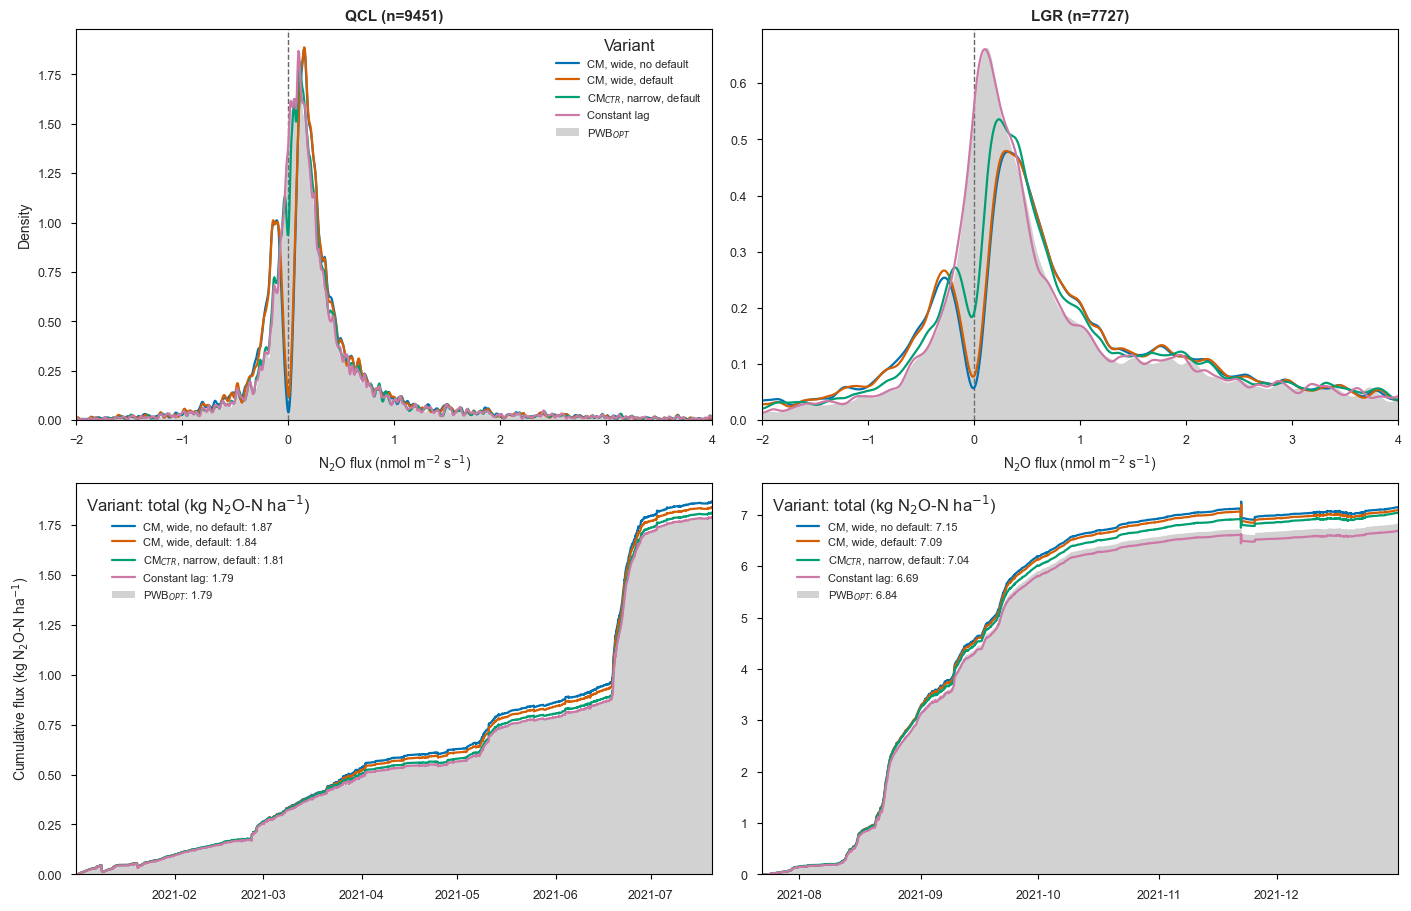

Saved ..\figures\04_cumulative_ch4.png


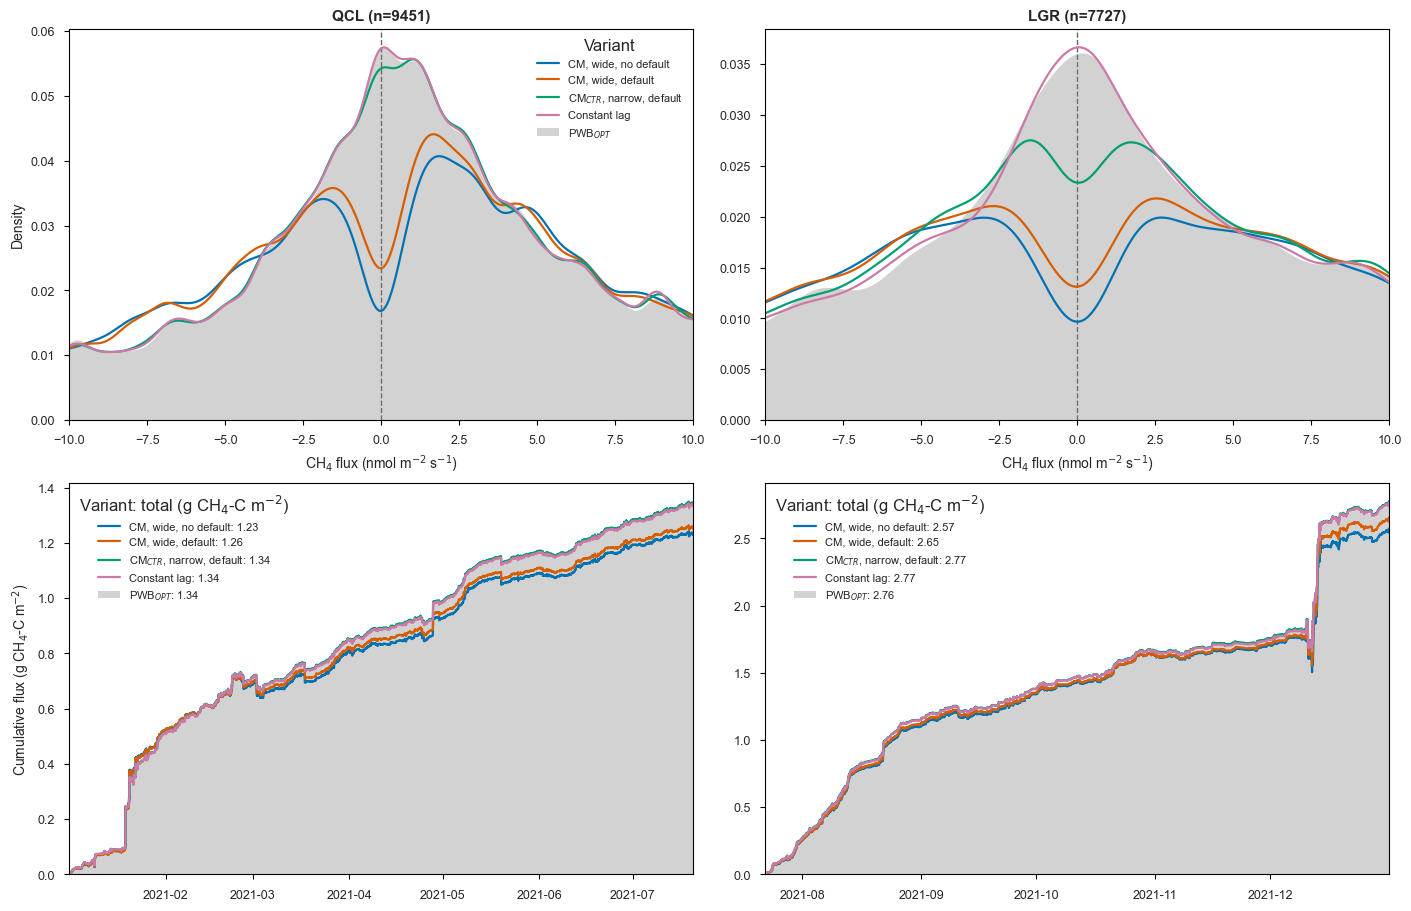

In [4]:
def style_axes(ax):
    """Black spines, short outward ticks, no grid."""
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)
    ax.tick_params(which="major", length=3.5, width=0.8, direction="out", color="black")


DENS_XLIM = {"N2O": (-2, 4), "CH4": (-10, 10)}  # fixed density x-range per gas (flux units)
KDE_N = 1000           # points on the density x-grid
KDE_BW_FACTOR = 0.2   # smoothing: smaller = sharper (resolves the near-zero dip)


def flux_kde(x, xs):
    """KDE of a flux sample on xs with a robust, lightly smoothed bandwidth. scipy's
    default scales the bandwidth by the standard deviation, which the heavy-tailed
    covariance-maximization variants inflate, smearing away the sharp near-zero
    mirroring dip. Basing the bandwidth on min(std, IQR/1.349) and undersmoothing
    (KDE_BW_FACTOR < 1) keeps that bimodal structure visible."""
    x = np.asarray(x, dtype=float)
    std = float(x.std())
    q75, q25 = np.percentile(x, [75, 25])
    robust = min(std, (q75 - q25) / 1.349) if q75 > q25 else std
    if std == 0 or robust == 0:
        robust = std = 1.0  # degenerate guard (does not occur for real flux)
    bw = KDE_BW_FACTOR * x.size ** (-1 / 5) * robust / std  # effective bw = factor*robust
    return gaussian_kde(x, bw_method=bw)(xs)


for gas, v in GASES.items():
    factor, cum_unit, glabel = v["factor"], v["cum_unit"], v["label"]
    fig, axes = plt.subplots(2, len(ANALYZERS), figsize=(14, 9),
                             constrained_layout=True, squeeze=False)
    for ci, analyzer in enumerate(ANALYZERS):
        ax_den, ax_cum = axes[0, ci], axes[1, ci]

        # The variants of this campaign, already aligned and reduced to their
        # common (paired) samples above, so the density distributions (top) and the
        # cumulative budgets (bottom) describe exactly the same set of half-hours.
        common = paired[(analyzer, gas)]

        # Row 1: flux density distribution per variant, a lightly smoothed kernel
        # density line over the common samples (cf. Vitale et al. 2024, Fig. 7). A
        # dashed line marks zero flux; the covariance-maximization variants lose
        # mass around zero (the "mirroring" bias, a bimodal dip) while the PWB_OPT
        # variant, drawn as a grey shaded area (no line) as the reference, keeps it.
        # The x-range is fixed per gas (DENS_XLIM) and flux_kde undersmooths, so the
        # dip is not smeared out by the heavy-tailed CM variants.
        lo, hi = DENS_XLIM[gas]
        xs = np.linspace(lo, hi, KDE_N)
        ax_den.axvline(0, color="0.4", ls="--", lw=1.0, zorder=0.5)
        for var in VARIANTS:
            dens = flux_kde(common[var].to_numpy(), xs)
            if var == 5:  # PWB_OPT reference: grey shaded area only, no line
                ax_den.fill_between(xs, 0, dens, color=VAR_COLORS[var], alpha=0.35, lw=0,
                                    zorder=0.8, label=VARIANT_NAMES[var])
            else:
                ax_den.plot(xs, dens, lw=1.6, color=VAR_COLORS[var], label=VARIANT_NAMES[var])
        ax_den.set_xlim(lo, hi)
        ax_den.set_ylim(bottom=0)
        ax_den.set_xlabel(f"{glabel} flux (nmol m$^{{-2}}$ s$^{{-1}}$)")
        ax_den.set_title(f"{analyzer} (n={common.shape[0]})", fontweight="bold")
        style_axes(ax_den)

        # Row 2: cumulative budget per variant over the same common samples,
        # integrated from the half-hourly flux into a cumulative mass. Each
        # variant's overall total (final cumulative value) is shown in the legend.
        # The PWB_OPT reference is drawn as a grey shaded area (no line), matching
        # the density row.
        cum = common.cumsum() * factor
        for var in VARIANTS:
            total = cum[var].iloc[-1] if len(cum) else float("nan")
            lbl = f"{VARIANT_NAMES[var]}: {total:.3g}"
            if var == 5:  # PWB_OPT reference: grey shaded area (no line)
                ax_cum.fill_between(cum.index, 0, cum[var], color=VAR_COLORS[var],
                                    alpha=0.35, lw=0, zorder=0.8, label=lbl)
            else:
                ax_cum.plot(cum.index, cum[var], lw=1.6, color=VAR_COLORS[var], label=lbl)
        if len(cum.index):
            ax_cum.set_xlim(cum.index.min(), cum.index.max())
        ax_cum.set_ylim(bottom=0)  # start the y-axis at exactly zero
        style_axes(ax_cum)
        ax_cum.legend(fontsize=8, loc="upper left", title=f"Variant: total ({cum_unit})")

    axes[0, 0].set_ylabel("Density")
    axes[0, 0].legend(fontsize=8, loc="upper right", title="Variant")
    axes[1, 0].set_ylabel(f"Cumulative flux ({cum_unit})")
    out = FIGDIR / f"04_cumulative_{gas.lower()}.png"
    fig.savefig(out, dpi=DPI, bbox_inches="tight")
    print(f"Saved {out}")
    plt.show()

**Figure.** Level-1 (pre-quality-control) flux distribution and cumulative
budget per time-lag variant, one figure per gas (N₂O first, then CH₄), with the
QCL campaign (2021_1) on the left and the LGR campaign (2021_2) on the right,
over the paired common samples. Top row: the half-hourly flux density, with a
dashed line at zero flux. Bottom row: the running budget, in kg N₂O-N ha⁻¹ for
N₂O and g CH₄-C m⁻² for CH₄, each variant's total in the legend. PWB$_{OPT}$ is
the grey shaded reference area in both rows. Saved as
`figures/04_cumulative_{gas}.png`.

## Runtime

In [5]:
NB_END = datetime.now()
print(f"Start:    {NB_START:%Y-%m-%d %H:%M:%S}")
print(f"End:      {NB_END:%Y-%m-%d %H:%M:%S}")
print(f"Runtime:  {NB_END - NB_START}")

Start:    2026-07-23 16:24:26
End:      2026-07-23 16:24:33
Runtime:  0:00:06.674305
